# Phase 2 Results

This notebook summarizes Phase 2 training/evaluation outputs, compares experiment runs, and previews generated plots.

In [1]:
import json
import sys
from pathlib import Path

import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.image as mpimg

def find_project_root(start: Path) -> Path:
    for p in [start, *start.parents]:
        if (p / 'src' / 'spotify_ml').exists():
            return p
    raise RuntimeError('Could not find project root (expected src/spotify_ml).')

ROOT = find_project_root(Path.cwd())
sys.path.insert(0, str(ROOT / 'src'))
RESULTS_DIR = ROOT / 'results'

print('Project root:', ROOT)
print('Results dir :', RESULTS_DIR)

Project root: C:\Users\K.Shokraneh\Projs\ML\Spotify
Results dir : C:\Users\K.Shokraneh\Projs\ML\Spotify\results


## Main Metrics (Latest Aggregate Files)

In [2]:
def load_json(path: Path):
    if not path.exists():
        return None
    return json.loads(path.read_text(encoding='utf-8'))

reg_main = load_json(RESULTS_DIR / 'regression' / 'metrics.json')
cls_main = load_json(RESULTS_DIR / 'classification' / 'metrics.json')

print('== REGRESSION ==')
print(reg_main if reg_main is not None else 'No regression metrics.json found')
print('\n== CLASSIFICATION ==')
print(cls_main if cls_main is not None else 'No classification metrics.json found')

== REGRESSION ==
{'baseline': {'mae': 8.20844658201461, 'rmse': 10.330196997641325, 'r2': 0.08070060408471458}, 'improved': {'mae': 6.14701871657754, 'rmse': 8.301832188166735, 'r2': 0.40627181181526395}}

== CLASSIFICATION ==
{'baseline': {'accuracy': 0.8241654913023038, 'precision': 0.7058201058201058, 'recall': 0.8741808650065531, 'f1': 0.7810304449648712, 'roc_auc': 0.9080723951987638, 'threshold': 0.5}, 'improved': {'accuracy': 0.8838740009402914, 'precision': 0.8394736842105263, 'recall': 0.836173001310616, 'f1': 0.8378200919238346, 'roc_auc': 0.9508615090148089, 'threshold': 0.5}}


## Model Comparison Tables (Run-Name Experiments)

In [3]:
def collect_task_runs(task: str):
    task_dir = RESULTS_DIR / task
    rows = []
    if not task_dir.exists():
        return pd.DataFrame()

    for d in sorted(task_dir.iterdir()):
        if not d.is_dir():
            continue
        metrics_path = d / 'metrics.json'
        if not metrics_path.exists():
            continue
        payload = json.loads(metrics_path.read_text(encoding='utf-8'))
        row = {'run': d.name}

        baseline = payload.get('baseline', {})
        improved = payload.get('improved', {})

        for k, v in baseline.items():
            row[f'baseline_{k}'] = v
        for k, v in improved.items():
            row[f'improved_{k}'] = v

        row['fe'] = 1 if '_fe1_' in d.name else 0
        row['tune'] = 1 if '_tu1_' in d.name else 0
        row['thr_opt'] = 1 if '_ot1' in d.name else 0
        rows.append(row)

    return pd.DataFrame(rows)

reg_df = collect_task_runs('regression')
cls_df = collect_task_runs('classification')

if reg_df.empty:
    print('No run-name regression metrics found under results/regression/<run>/metrics.json')
else:
    reg_cols = [
        'run', 'fe', 'tune',
        'baseline_mae', 'baseline_rmse', 'baseline_r2',
        'improved_mae', 'improved_rmse', 'improved_r2',
    ]
    reg_view = reg_df[[c for c in reg_cols if c in reg_df.columns]].copy()
    reg_view = reg_view.sort_values(['improved_r2', 'improved_rmse', 'improved_mae'], ascending=[False, True, True])
    display(reg_view.reset_index(drop=True))

if cls_df.empty:
    print('No run-name classification metrics found under results/classification/<run>/metrics.json')
else:
    cls_cols = [
        'run', 'fe', 'tune', 'thr_opt',
        'baseline_accuracy', 'baseline_f1', 'baseline_roc_auc', 'baseline_threshold',
        'improved_accuracy', 'improved_f1', 'improved_roc_auc', 'improved_threshold',
    ]
    cls_view = cls_df[[c for c in cls_cols if c in cls_df.columns]].copy()
    cls_view = cls_view.sort_values(['improved_f1', 'improved_accuracy', 'improved_roc_auc'], ascending=[False, False, False])
    display(cls_view.reset_index(drop=True))

,run,fe,tune,baseline_mae,baseline_rmse,baseline_r2,improved_mae,improved_rmse,improved_r2
0,reg_fe0_tu1,0,0,8.208447,10.330197,0.080701,6.134554,8.277470,0.409751
1,reg_fe1_tu1,1,0,7.984778,10.068712,0.126651,6.143137,8.278640,0.409585
2,reg_fe1_tu0,1,0,7.984778,10.068712,0.126651,6.146150,8.285134,0.408658
3,reg_fe0_tu0,0,0,8.208447,10.330197,0.080701,6.147019,8.301832,0.406272
4,baseline,0,0,NaN,NaN,NaN,NaN,NaN,NaN
5,improved,0,0,NaN,NaN,NaN,NaN,NaN,NaN


,run,fe,tune,thr_opt,baseline_accuracy,baseline_f1,baseline_roc_auc,baseline_threshold,improved_accuracy,improved_f1,improved_roc_auc,improved_threshold
0,cls_fe0_tu1_ot1,0,1,1,0.824165,0.781030,0.908072,0.5,0.884814,0.842444,0.951049,0.47
1,cls_fe0_tu0_ot1,0,0,1,0.824165,0.781030,0.908072,0.5,0.883404,0.840617,0.950862,0.47
2,cls_fe1_tu0_ot1,1,0,1,0.825576,0.783925,0.911611,0.5,0.883404,0.840206,0.949737,0.48
3,cls_fe0_tu0_ot0,0,0,0,0.824165,0.781030,0.908072,0.5,0.883874,0.837820,0.950862,0.50
4,cls_fe0_tu1_ot0,0,1,0,0.824165,0.781030,0.908072,0.5,0.883404,0.837270,0.951049,0.50
5,cls_fe1_tu1_ot0,1,1,0,0.825576,0.783925,0.911611,0.5,0.879643,0.833766,0.949053,0.50
6,cls_fe1_tu1_ot1,1,1,1,0.825576,0.783925,0.911611,0.5,0.879173,0.831696,0.949053,0.51
7,cls_fe1_tu0_ot0,1,0,0,0.825576,0.783925,0.911611,0.5,0.877762,0.829620,0.949737,0.50
8,baseline,0,0,0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
9,improved,0,0,0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


## Best-Run Snapshot

In [4]:
best_reg = None
best_cls = None

if not reg_df.empty and 'improved_r2' in reg_df.columns:
    best_reg = reg_df.sort_values(['improved_r2', 'improved_rmse', 'improved_mae'], ascending=[False, True, True]).iloc[0]

if not cls_df.empty and 'improved_f1' in cls_df.columns:
    best_cls = cls_df.sort_values(['improved_f1', 'improved_accuracy', 'improved_roc_auc'], ascending=[False, False, False]).iloc[0]

print('Best regression run :', None if best_reg is None else best_reg['run'])
print('Best classification run:', None if best_cls is None else best_cls['run'])

Best regression run : reg_fe0_tu1
Best classification run: cls_fe0_tu1_ot1


## Plot Gallery (Best Runs)

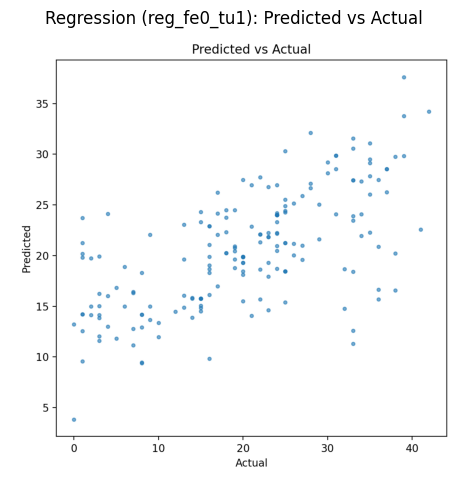

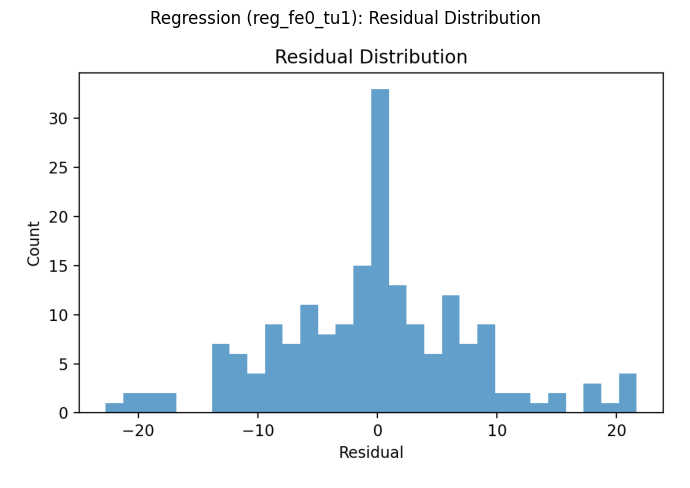

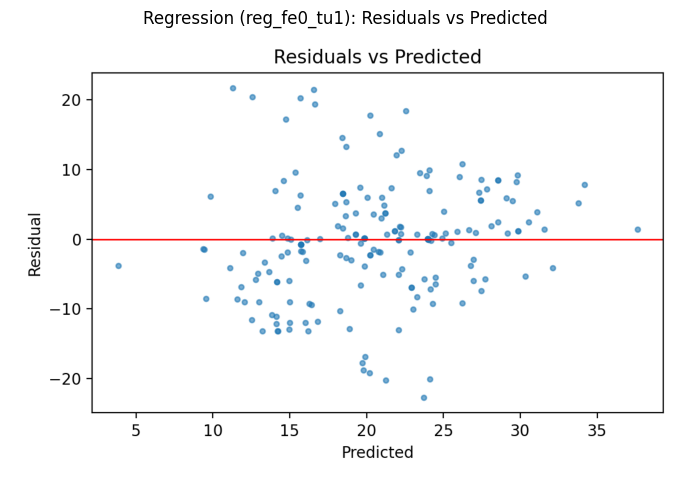

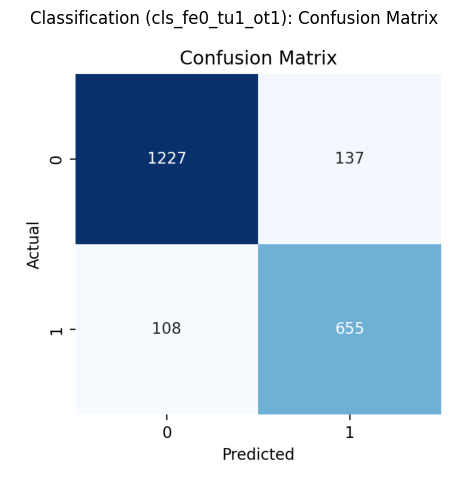

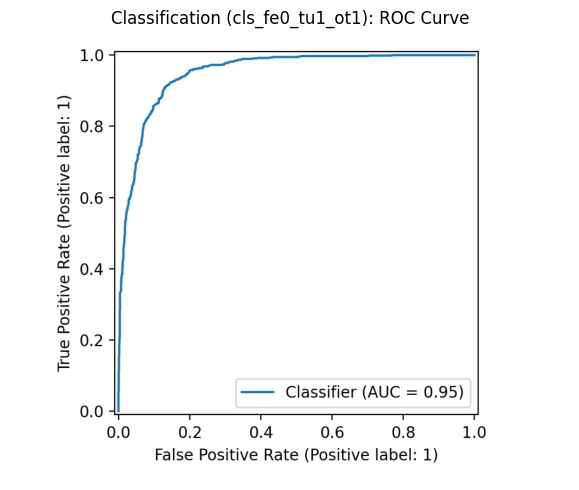

In [5]:
def show_image(path: Path, title: str):
    if not path.exists():
        print(f'Missing: {path}')
        return
    img = mpimg.imread(path)
    plt.figure(figsize=(7, 5))
    plt.imshow(img)
    plt.title(title)
    plt.axis('off')
    plt.tight_layout()
    plt.show()

if best_reg is not None:
    rr = RESULTS_DIR / 'regression' / best_reg['run'] / 'improved' / 'figures'
    show_image(rr / 'pred_vs_actual.png', f"Regression ({best_reg['run']}): Predicted vs Actual")
    show_image(rr / 'residuals_hist.png', f"Regression ({best_reg['run']}): Residual Distribution")
    show_image(rr / 'residuals_vs_pred.png', f"Regression ({best_reg['run']}): Residuals vs Predicted")

if best_cls is not None:
    cr = RESULTS_DIR / 'classification' / best_cls['run'] / 'improved' / 'figures'
    show_image(cr / 'confusion_matrix.png', f"Classification ({best_cls['run']}): Confusion Matrix")
    show_image(cr / 'roc_curve.png', f"Classification ({best_cls['run']}): ROC Curve")